In [97]:
import numpy as np
import pandas as pd
import hdbscan

In [98]:
df = pd.read_csv(r"dataset\preprocessing\prePro-news_balanced.csv")
embeddings = np.load(r"dataset\embeddings\balanced_episode_embeddings.npy")
df['timestamp'] = pd.to_datetime(df['published_date'])

print("Embeddings Shape:", embeddings.shape)

Embeddings Shape: (1291, 385)


## Episode Discovery using HDBSCAN

In [99]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=8,
    min_samples=3,
    metric='euclidean'
)

labels = clusterer.fit_predict(embeddings)

print("Unique Clusters:", np.unique(labels))

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Unique Clusters: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [100]:
df['episode'] = labels

print(df['episode'].value_counts())

-1     813
 19    100
 15     36
 9      35
 18     33
 3      26
 4      25
 6      22
 17     20
 10     20
 16     20
 12     19
 8      15
 1      15
 7      15
 2      14
 14     12
 11     12
 20     11
 13     10
 5       9
 0       9
Name: episode, dtype: int64


## Dimentionality Reduction

In [101]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

print("UMAP Shape:", embedding_2d.shape)

c:\Users\gaura\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP Shape: (1291, 2)


## Episode cluster visualization

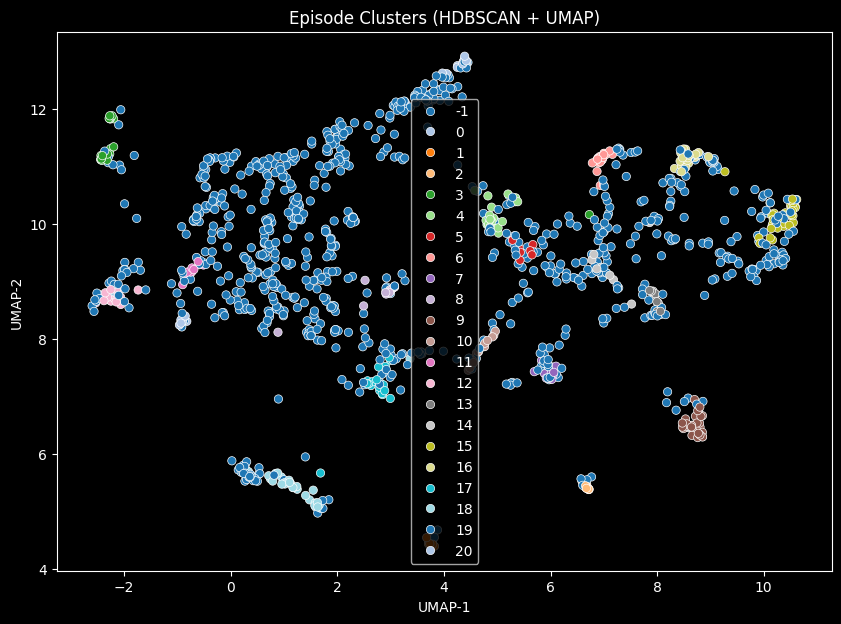

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=embedding_2d[:,0],
    y=embedding_2d[:,1],
    hue=labels,
    palette="tab20",
    legend='full'
)

plt.title("Episode Clusters (HDBSCAN + UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

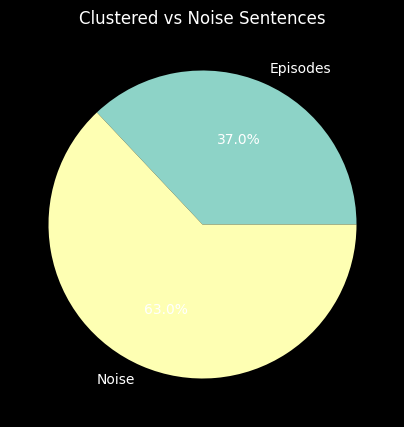

In [103]:
noise = np.sum(labels == -1)
clustered = np.sum(labels != -1)

plt.figure(figsize=(5,5))
plt.pie(
    [clustered, noise],
    labels=["Episodes", "Noise"],
    autopct='%1.1f%%'
)
plt.title("Clustered vs Noise Sentences")
plt.show()

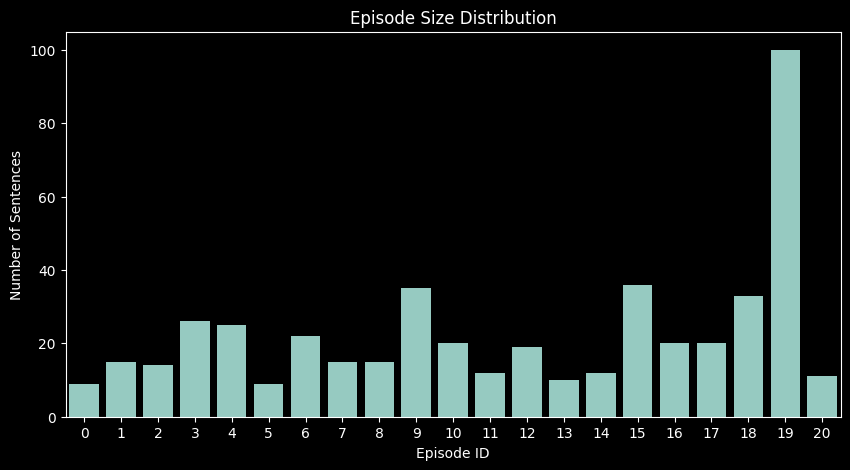

In [104]:
episode_sizes = df[df['episode'] != -1]['episode'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(
    x=episode_sizes.index,
    y=episode_sizes.values
)

plt.title("Episode Size Distribution")
plt.xlabel("Episode ID")
plt.ylabel("Number of Sentences")
plt.show()

In [105]:
t0 = df['timestamp'].min()
df['t'] = (df['timestamp'] - t0).dt.days
df['t_norm'] = df['t'] / df['t'].max()

In [106]:
episode_time_spread = df[df['episode'] != -1].groupby('episode')['t_norm'].std()

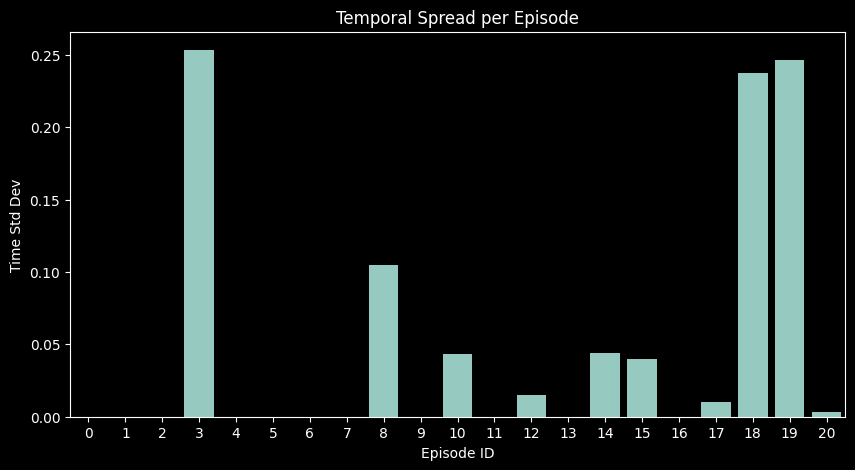

In [107]:
plt.figure(figsize=(10,5))
sns.barplot(
    x=episode_time_spread.index,
    y=episode_time_spread.values
)

plt.title("Temporal Spread per Episode")
plt.xlabel("Episode ID")
plt.ylabel("Time Std Dev")
plt.show()

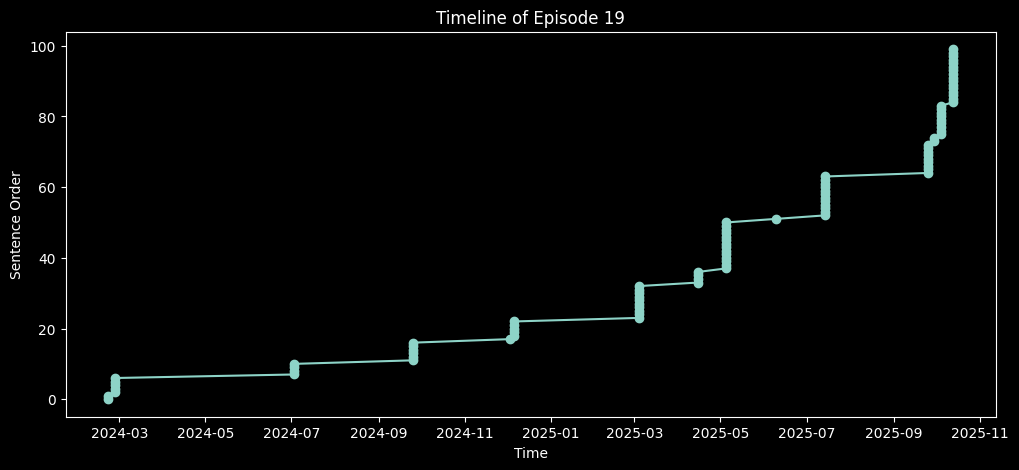

In [108]:
episode_id =19

episode_df = df[df['episode'] == episode_id].sort_values('timestamp')

plt.figure(figsize=(12,5))
plt.plot(episode_df['timestamp'], range(len(episode_df)), marker='o')

plt.title(f"Timeline of Episode {episode_id}")
plt.xlabel("Time")
plt.ylabel("Sentence Order")
plt.show()

## Semantic Coherence Check

In [109]:
sample = df[df['episode'] == episode_id]['sentence'].sample(10, random_state=42)

for s in sample:
    print("-", s)

- Some European countries are further along with 5G adoption, like Denmark at 40% or Germany at 50%.
- The cost of upgrading hardware to be 5G-ready can be a concern for smaller farms.
- He says with faster speeds and near-instant connectivity, 5G can support complex technologies like real-time holographic imaging.
- “They will ask their farm workers to try watering more or add more fertiliser.
- Tan believes the rollout of 5G could unlock new possibilities for farming.
- There are existing technologies, but we see that 5G Broadcast will also help in that direction,” he added. 5G Broadcast technology is the latest evolution in telecommunications, allowing content to be transmitted directly to mobile devices without the need for traditional Internet connections
- But with 5G, one operator can manage multiple drones.
- The European Union's slow adoption of 5G networks and lagging performance compared to other regions is lamented by both telecoms operators and industrial firms hoping to b

In [110]:
episode_time = df[df['episode'] == episode_id]['timestamp']

print("Start:", episode_time.min())
print("End:", episode_time.max())

Start: 2024-02-22 00:00:00
End: 2025-10-13 00:00:00


In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts = df[df['episode'] == episode_id]['sentence']

vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
X = vectorizer.fit_transform(texts)

print(vectorizer.get_feature_names_out())

['5g' 'areas' 'coverage' 'malaysia' 'mobile' 'network' 'new' 'said' 'says'
 'technology']


In [112]:
from sklearn.metrics.pairwise import cosine_similarity

indices = df[df['episode'] == episode_id].index
cluster_embeddings = embeddings[indices]

sim = cosine_similarity(cluster_embeddings)

print("Average Similarity:", sim.mean())

Average Similarity: 0.5139593617959702


In [127]:
episode_df[
    ["content_id", "sentence", "published_date", "category", "episode"]
].to_csv(r"dataset\episodes\episode_balanced.csv",index=False)